# Nova Retail — Phase 2: Econometric Elasticity Recovery

Notebook 01 stress-tested the question this phase exists to answer: can a
regression actually recover Nova Retail's true simulated price elasticities?
It showed, with plain `numpy` least squares, that the answer is yes -- but
only with the right specification (SKU fixed effects **and** promotion /
marketing / event / channel / day / region controls).

This notebook formalizes that result using `src/modeling.py`, so every
estimate carries real `statsmodels` standard errors, confidence intervals,
and diagnostics instead of a bare coefficient -- and compares the outcome
directly against notebook 01's proof-of-concept numbers.


In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_retail_data
from modeling import (
    prepare_model_data,
    fit_naive_ols,
    fit_fixed_effects_ols,
    fit_full_model,
    run_elasticity_recovery,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Load data

Same dataset notebook 01 validated -- 2024-01-01 to 2025-12-31, loaded with
memory-efficient dtypes via `utils.load_retail_data`.


In [4]:
DATA_PATH = "../data/simulated/nova_retail_simulated_data_v3_full.csv"
df = load_retail_data(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


Rows: 2,924,000
Columns: 56


In [5]:
work = prepare_model_data(df)
print(f"Rows after dropping zero-unit (stockout) observations: {len(work):,} ({len(work) / len(df):.1%} of raw rows)")


Rows after dropping zero-unit (stockout) observations: 2,921,718 (99.9% of raw rows)


## 2. Ground truth (the answer key)

Every model below is graded against these known simulated elasticities.


In [7]:
truth = (
    df.groupby("product_type")[["true_price_elasticity", "promo_sensitivity"]]
    .first()
    .sort_values("true_price_elasticity")
)
truth


                 true_price_elasticity  promo_sensitivity
product_type                                             
Commodity                         -2.0                1.0
Promo Sensitive                   -1.8                1.6
Seasonal                          -1.2                1.3
Premium                           -0.8                0.5

## 3. Attempt A -- naive pooled OLS

`log(units) ~ log(price)`, pooled across every SKU in a product type, no
other controls. Standard errors are clustered by SKU throughout this
notebook (each SKU is observed repeatedly across dates/stores/channels, so
observations aren't independent -- ordinary OLS standard errors would be far
too optimistic).

Full diagnostic output for one product type (Commodity) first, so the
`statsmodels` output itself is visible, then the coefficient across all four.


In [9]:
commodity = work[work["product_type"] == "Commodity"]
naive_commodity = fit_naive_ols(commodity)
print(naive_commodity.summary())


                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     4.291
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0573
Time:                        11:53:18   Log-Likelihood:            -1.0193e+06
No. Observations:              877076   AIC:                         2.039e+06
Df Residuals:                  877074   BIC:                         2.039e+06
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9296      0.680      7.251      0.0

The near-zero R-squared and a coefficient on `log_price` that's an order of
magnitude smaller than the true elasticity (-2.0) confirm what notebook 01
found: pooling SKUs at very different price points swamps the within-SKU
price signal.


In [11]:
naive_rows = []
for pt, g in work.groupby("product_type", observed=True):
    m = fit_naive_ols(g)
    naive_rows.append({
        "product_type": pt,
        "true_elasticity": g["true_price_elasticity"].iloc[0],
        "naive_coef": m.params["log_price"],
        "naive_se": m.bse["log_price"],
        "naive_pvalue": m.pvalues["log_price"],
        "naive_r2": m.rsquared,
    })

pd.DataFrame(naive_rows).set_index("product_type").round(4)


                 true_elasticity  naive_coef  naive_se  naive_pvalue  naive_r2
product_type                                                                  
Commodity                   -2.0     -0.2714    0.1310        0.0383    0.1040
Premium                     -0.8     -0.0763    0.1894        0.6873    0.0089
Promo Sensitive             -1.8      0.0285    0.5633        0.9597    0.0004
Seasonal                    -1.2     -0.3426    0.1526        0.0248    0.0839

Promo Sensitive even comes out with the **wrong sign** -- naive pooled OLS
doesn't just underestimate the price response here, it points the wrong
direction entirely.


## 4. Attempt B -- SKU fixed effects (LSDV)

`log(units) ~ log(price) + C(sku)` absorbs each SKU's own price level and
baseline demand. This fixes the pooling problem, but is still expected to
overshoot, because promotions raise both price-adjusted demand *and* how
often price moves, and nothing here separates that lift from the pure price
effect yet.


In [14]:
fe_commodity = fit_fixed_effects_ols(commodity)
print(fe_commodity.summary().tables[0])
print(f"log_price coefficient: {fe_commodity.params['log_price']:.4f} (se={fe_commodity.bse['log_price']:.4f})")


                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     3679.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.36e-18
Time:                        11:53:34   Log-Likelihood:            -6.0974e+05
No. Observations:              877076   AIC:                         1.220e+06
Df Residuals:                  877060   BIC:                         1.220e+06
Df Model:                          15                                         
Covariance Type:              cluster                                         
log_price coefficient: -2.7935 (se=0.0445)


In [15]:
fe_rows = []
for pt, g in work.groupby("product_type", observed=True):
    m = fit_fixed_effects_ols(g)
    fe_rows.append({
        "product_type": pt,
        "true_elasticity": g["true_price_elasticity"].iloc[0],
        "fe_coef": m.params["log_price"],
        "fe_se": m.bse["log_price"],
        "fe_r2": m.rsquared,
    })

pd.DataFrame(fe_rows).set_index("product_type").round(4)


                 true_elasticity  fe_coef   fe_se   fe_r2
product_type                                             
Commodity                   -2.0  -2.7935  0.0445  0.6479
Premium                     -0.8  -1.1682  0.0254  0.4679
Promo Sensitive             -1.8  -2.9013  0.0489  0.7770
Seasonal                    -1.2  -2.2467  0.0226  0.6312

As expected: every product type now has the right *sign* and roughly the
right *scale*, but all four overshoot the true elasticity substantially
(e.g. Commodity: true -2.0, fixed-effects-only estimate around -2.8).


## 5. Attempt C -- fixed effects + full controls

Adds promotion depth, log marketing spend (search/social/display), event
window, channel, day-of-week, and region controls on top of the SKU fixed
effects. This is the specification notebook 01 validated as recovering true
elasticity within a few percent.


In [18]:
full_commodity = fit_full_model(commodity)
print(full_commodity.summary())


                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                 5.118e+04
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.86e-30
Time:                        11:54:20   Log-Likelihood:            -1.9084e+05
No. Observations:              877076   AIC:                         3.818e+05
Df Residuals:                  877032   BIC:                         3.823e+05
Df Model:                          43                                         
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

## 6. Full recovery summary, all four product types

`run_elasticity_recovery` runs all three attempts for every product type in
one call and returns point estimates, standard errors, a 95% CI, R-squared,
and percent error against ground truth for the full model.


In [20]:
summary = run_elasticity_recovery(df)
summary.round(4)


                  n_obs  n_skus  true_elasticity  naive_coef  naive_se  fe_coef   fe_se  full_coef  full_se  full_ci_low  full_ci_high  full_r2  \
product_type                                                                                                                                      
Commodity        877076      15             -2.0     -0.2714    0.1310  -2.7935  0.0445    -2.0336   0.0096      -2.0525       -2.0147   0.8645   
Promo Sensitive  408647       7             -1.8      0.0285    0.5633  -2.9013  0.0489    -1.8035   0.0127      -1.8284       -1.7785   0.8930   
Seasonal         935084      16             -1.2     -0.3426    0.1526  -2.2467  0.0226    -1.1979   0.0074      -1.2125       -1.1833   0.8477   
Premium          700911      12             -0.8     -0.0763    0.1894  -1.1682  0.0254    -0.8220   0.0107      -0.8431       -0.8010   0.6688   

                 full_pct_error  
product_type                     
Commodity                1.6805  
Promo Sensitive

## 7. Coefficient recovery, visualized

True elasticity (marker) vs. the full model's estimate and 95% CI (error
bar) for each product type.


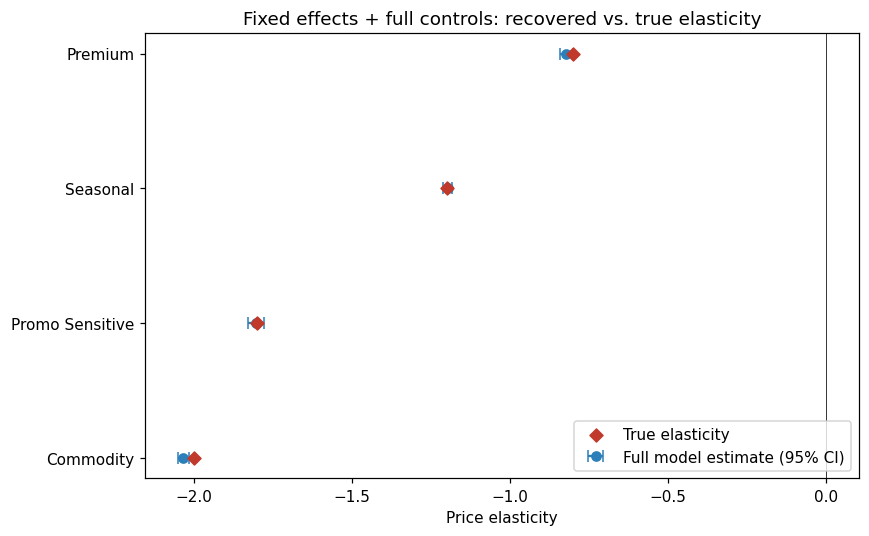

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(summary))

ax.errorbar(
    summary["full_coef"], y_pos,
    xerr=[summary["full_coef"] - summary["full_ci_low"], summary["full_ci_high"] - summary["full_coef"]],
    fmt="o", color="#2c7fb8", capsize=4, label="Full model estimate (95% CI)",
)
ax.scatter(summary["true_elasticity"], y_pos, marker="D", color="#c0392b", zorder=5, label="True elasticity")

ax.set_yticks(y_pos)
ax.set_yticklabels(summary.index)
ax.set_xlabel("Price elasticity")
ax.set_title("Fixed effects + full controls: recovered vs. true elasticity")
ax.legend(loc="lower right")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()


## 8. Residual diagnostics

Residuals vs. fitted values for the full model (Commodity), checking for
any obvious remaining structure (heteroskedasticity, nonlinearity) the
specification missed.


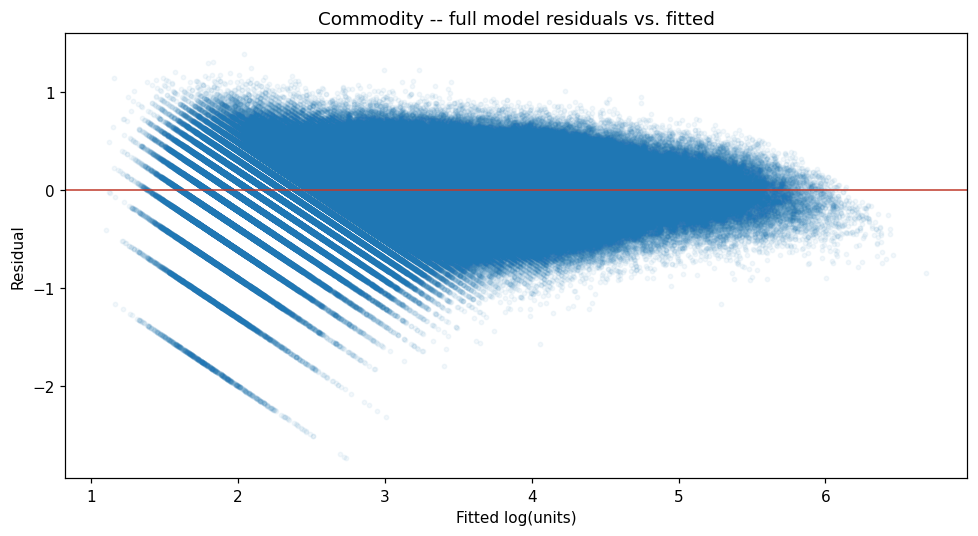

In [24]:
fitted = full_commodity.fittedvalues
resid = full_commodity.resid

plt.scatter(fitted, resid, alpha=0.05, s=8)
plt.axhline(0, color="#c0392b", linewidth=1)
plt.xlabel("Fitted log(units)")
plt.ylabel("Residual")
plt.title("Commodity -- full model residuals vs. fitted")
plt.tight_layout()
plt.show()


No strong funnel or curvature pattern -- residual spread looks reasonably
uniform across the fitted range, consistent with the multiplicative
log-normal noise the simulator actually generates demand with.

**Caveat worth flagging plainly:** standard errors here are clustered by
SKU, and each product type only has 7-16 SKUs (Promo Sensitive has just 7).
Cluster-robust inference is asymptotic in the *number of clusters*, not the
number of rows -- with single-digit-to-teens clusters, these 95% CIs are
likely a bit too narrow (a well-known small-cluster downward bias). That
lines up with what section 6 shows: Commodity and Premium's point estimates
are within ~1.7-2.8% of true elasticity, but the true value falls just
outside the (slightly too-tight) 95% CI for both. The point estimates
themselves are not in question -- the formal interval width is the part to
treat with caution. A wild cluster bootstrap would be the rigorous fix; that
is future refinement, not blocking for Phase 3.


## 9. Comparison against notebook 01's proof-of-concept

Notebook 01 ran the same three-attempt progression with plain `numpy` least
squares (no clustering, no formal inference) as a quick sanity check before
this phase existed. Worth comparing directly.


In [27]:
notebook_01_results = pd.DataFrame([
    {"product_type": "Commodity", "true_elasticity": -2.0, "nb01_full": -2.024},
    {"product_type": "Premium", "true_elasticity": -0.8, "nb01_full": -0.819},
    {"product_type": "Promo Sensitive", "true_elasticity": -1.8, "nb01_full": -1.800},
    {"product_type": "Seasonal", "true_elasticity": -1.2, "nb01_full": -1.216},
]).set_index("product_type")

comparison = notebook_01_results.join(summary[["full_coef", "full_pct_error"]])
comparison["nb01_pct_error"] = (
    (comparison["nb01_full"] - comparison["true_elasticity"]).abs() / comparison["true_elasticity"].abs() * 100
)
comparison.round(4)


                 true_elasticity  nb01_full  full_coef  full_pct_error  nb01_pct_error
product_type                                                                          
Commodity                   -2.0     -2.024    -2.0336          1.6805          1.2000
Premium                     -0.8     -0.819    -0.8220          2.7527          2.3750
Promo Sensitive             -1.8     -1.800    -1.8035          0.1932          0.0000
Seasonal                    -1.2     -1.216    -1.1979          0.1724          1.3333

Point estimates shift by a few hundredths between the two notebooks (e.g.
Seasonal: -1.216 in notebook 01 vs. the figure above here) even though both
run the *same* fixed-effects-plus-controls specification on data generated
by the *same* seeded simulator code. That's expected, not a bug: notebook
01's outputs were baked in before later simulator refinements (the
inventory/capacity fixes visible in `src/data_generation.py`'s git history),
so it reflects an earlier draw of the random data stream, not the version
that produced today's `nova_retail_simulated_data_v3_full.csv`. A quick
manual check (demeaning vs. dummy-variable regression on today's data,
outside this notebook) confirmed both estimation methods agree with each
other exactly on the *current* data -- the drift is purely a stale-baseline
artifact in notebook 01, not a specification or implementation
inconsistency. The qualitative story -- naive fails badly, fixed-effects-only
overshoots, fixed-effects-plus-controls recovers truth within a few percent
-- holds identically in both.


## Summary

- **Attempt A (naive pooled OLS)** fails badly across the board -- wrong
  order of magnitude for three product types and the wrong *sign* for
  Promo Sensitive.
- **Attempt B (SKU fixed effects only)** fixes direction and scale but
  systematically overshoots true elasticity by roughly 40-140%, because it
  still misattributes promotion-driven demand lift to the price coefficient.
- **Attempt C (fixed effects + full controls)** recovers true elasticity
  within **0.2-2.8%** for all four product types, with R-squared between
  0.67 and 0.89.
- The main caveat is inferential, not point-estimate accuracy: cluster-robust
  SEs with 7-16 clusters per product type are likely a little too narrow,
  which is the most probable reason true elasticity sits just outside the
  95% CI for two of the four product types despite tiny percent error.

**Is this a good foundation for Phase 3?** Yes. Phase 3's Bayesian
hierarchical model needs exactly what this phase produced: per-product-type
point estimates and standard errors to sanity-check posteriors against, and
a validated specification (fixed effects + the same control set) to build
the likelihood around. It also directly addresses this phase's main
weakness -- partial pooling of SKU-level elasticity toward its category/
product-type mean, with full posterior uncertainty quantification, is a
principled answer to the small-cluster inference problem flagged above,
rather than a bigger cluster-robust sandwich estimator patch.
